# CQF Final Project

***

# Notebook Settings

In [1]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Silence TensorFlow C++ stderr warnings (0=all, 1=no INFO, 2=no INFO/WARN, 3=no INFO/WARN/ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# OneDNN speeds CPU matmuls. Must be set before importing TensorFlow.
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '1')
os.environ.setdefault('TF_NUM_INTRAOP_THREADS', str(os.cpu_count() or 4))
os.environ.setdefault('TF_NUM_INTEROP_THREADS', '2')

# Automatically set working directory to root directory
if Path.cwd().name == 'model_building':
    PROJECT_PATH = Path.cwd().parent
else:
    PROJECT_PATH = Path.cwd()

os.chdir(PROJECT_PATH)

if str(PROJECT_PATH) not in sys.path:
    sys.path.append(str(PROJECT_PATH))

print(f"Working directory set to: {os.getcwd()}")

# Importing configuration and helper modules
from source.config import *
import pandas as pd
from source.helper import *
%run "./model_building/3_parked_functions_V1.ipynb"

# 4. Display options
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.width', 1000)

print("All imports executed perfectly!")


Working directory set to: c:\Users\mail2\OneDrive\coding projects\Final Project
[Logs] Project is on OneDrive. Writing tuner/TB logs locally to:
       C:\Users\mail2\AppData\Local\cqf_quant_model_logs
All imports executed perfectly!


# Data Import

In [2]:
data = np.load(PROJECT_PATH / "data" / "lstm_sequences.npz", allow_pickle=True)

X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]
seq_len = int(data["seq_len"])

train_dataset = make_tf_dataset(X_train, y_train, seq_len, batch_size=FIT_BATCH_SIZE, shuffle=False)
val_dataset = make_tf_dataset(X_test, y_test, seq_len, batch_size=FIT_BATCH_SIZE, shuffle=False)

SEQLEN = seq_len
NUMFEAT = X_train.shape[1]
class_weight = cwts(y_train)


In [3]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8876, 40)
(8876,)
(5918, 40)
(5918,)


In [4]:
#X.describe().T.style.format("{:.4f}")
#X.describe().T.round(4).to_csv(PROJECT_PATH + '/data/indicator_description.csv')

### Initial Experimentation: Recurrent Cell Comparison
- Quick proxy study of SimpleRNN vs GRU vs LSTM at fixed small capacity
- Justifies choosing LSTM before locking the baseline / HPO architecture


In [5]:
# Lightweight proxy run (few epochs) - does not affect baseline / HPO
cell_cmp_results = compare_recurrent_cells(
    X_train, y_train, X_test, y_test, class_weight,
    seqlen=SEQLEN, hu=16, learning_rate=0.005, epochs=3, seed=42
)


=== Initial Experimentation: Recurrent Cell Comparison ===

SimpleRNN: val_loss=0.4946  val_accuracy=0.7909
      GRU: val_loss=0.4861  val_accuracy=0.7785
     LSTM: val_loss=0.4937  val_accuracy=0.7974

Proxy winner (lowest val_loss): GRU


# Model Training

### Baseline Model

In [6]:
my_callbacks = [EarlyStopping(patience=20, monitor='val_loss', mode='min', verbose=1, restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)]

timestamp = int(time.time())
model, history = run_standard_training(
    project_name=f'lstm_baseline_{timestamp}',
    train_data=train_dataset,
    val_data=val_dataset,
    class_weight=class_weight,
    seqlen=SEQLEN,
    numfeat=NUMFEAT,
    hu=56,
    learning_rate=0.001,
    epochs=50,
    extra_callbacks=my_callbacks,
 )

--- Starting Standard Run: lstm_baseline_1787141928 ---
[TensorBoard] Baseline LSTM          run=lstm_baseline_1787141928 -> http://localhost:6006/#scalars&runFilter=lstm_baseline_1787141928
Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6340 - loss: 0.9044 - precision: 0.4857 - recall: 0.6238 - val_accuracy: 0.7473 - val_loss: 0.7080 - val_precision: 0.6789 - val_recall: 0.7432 - learning_rate: 0.0010
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7333 - loss: 0.6837 - precision: 0.5965 - recall: 0.7553 - val_accuracy: 0.7638 - val_loss: 0.6102 - val_precision: 0.7514 - val_recall: 0.6443 - learning_rate: 0.0010
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7720 - loss: 0.6022 - precision: 0.6480 - recall: 0.7754 - val_accuracy: 0.7748 - val_loss: 0.5703 - val_precision: 0.7483 - val_recall: 0.6897 - learning_rate: 0.0010
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7851 - loss: 0.5646 - precision: 0.6670 - rec

In [7]:
# After Cursor/kernel restart: relaunch TensorBoard on persisted event logs.
# Safe to re-run; does not retrain. New model runs replace/update the same boards.
restore_tensorboard_sessions()

[TensorBoard] Restoring 4 board(s) from disk...
[TensorBoard] Baseline LSTM          run=lstm_baseline_1787141928 -> http://localhost:6006/#scalars&runFilter=lstm_baseline_1787141928
[TensorBoard] Bayesian Optimization | botrial_1787138859 run=botrial_1787138859 -> http://localhost:6007/#scalars&runFilter=botrial_1787138859
[TensorBoard] Hyperband | hbtrial_1787139475 run=hbtrial_1787139475 -> http://localhost:6008/#scalars&runFilter=hbtrial_1787139475
[TensorBoard] Random Search | rstrail_1787138203 run=rstrail_1787138203 -> http://localhost:6009/#scalars&runFilter=rstrail_1787138203


{'C:\\Users\\mail2\\AppData\\Local\\cqf_quant_model_logs\\baseline\\lstm_baseline_1787141928': 'http://localhost:6006/#scalars&runFilter=lstm_baseline_1787141928',
 'C:\\Users\\mail2\\AppData\\Local\\cqf_quant_model_logs\\botrial_1787138859': 'http://localhost:6007/#scalars&runFilter=botrial_1787138859',
 'C:\\Users\\mail2\\AppData\\Local\\cqf_quant_model_logs\\hbtrial_1787139475': 'http://localhost:6008/#scalars&runFilter=hbtrial_1787139475',
 'C:\\Users\\mail2\\AppData\\Local\\cqf_quant_model_logs\\rstrail_1787138203': 'http://localhost:6009/#scalars&runFilter=rstrail_1787138203'}

### Save and Load best model


[Using the provided Keras Model directly]
Model successfully saved to best_lstm_baseline.keras!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM1 (LSTM)                    │ (None, 21, 112)        │        68,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout1 (Dropout)              │ (None, 21, 112)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM2 (LSTM)                    │ (None, 56)             │        37,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout2 (Dropout)              │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,373 (1.22 MB)

 Trainable params: 106,457 (415.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 212,916 (831.71 KB)


--- LSTM Model: Validation Performance ---
 - loss: 0.5195
 - compile_metrics: 0.7977

--- LSTM Model: Training Performance ---
 - loss: 0.6024
 - compile_metrics: 0.7283
Extracting model and generating metrics for: LSTM Baseline Model...


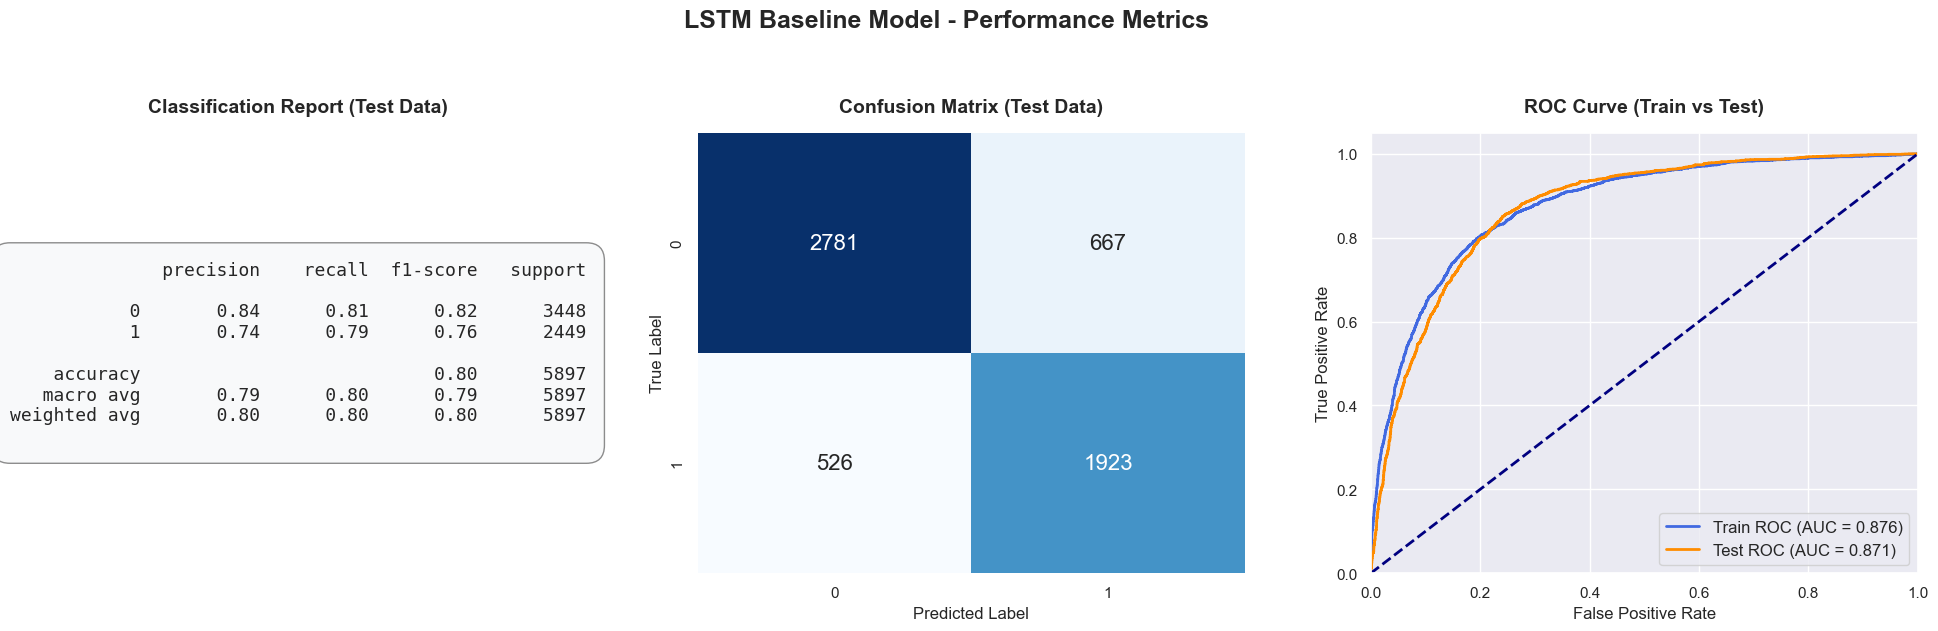

In [8]:
# Just pass the result directly!
final_model = save_and_evaluate(model, train_data=train_dataset, val_data=val_dataset)
# 2. Call the plotting function directly with the model!
plot_model_performance(training_result=model, train_data=train_dataset, val_data=val_dataset, run_name="LSTM Baseline Model")

# Hyperparameter Optimization
- The problem of choosing a set of optimal hyperparameters for a learning algorithm is called hyperparameter tuning or optimization. Hyperparameter is a training parameter whose value is

- used to control the learning process as compared to the values of other parameters (typically weights) that are learned

- set before training the model and are not learned by the model during the training process while model parameters are learned by the model, from the data, during the training process

- Some of the most common hyperparameters that can be optimised for better results are number of hidden layers, number of neurons, choice of activation function, number of epochs, learning rate, batch size and regularisation parameters.

- Our goal is to get best performing model by choosing parameters that help in getting a model that is both precise and generalized.


### KerasTuner
- The Keras Tuner is a library that helps you pick the optimal set of hyperparameters for your TensorFlow program. The two most uses classes are

- Hyperparameters class: used to specify a set of hyperparameters and their values that are to be used in the model building function.

- Tuner class: subclasses corresponding to different tuning algorithms that are called directly by the user to start the search or to get the best models. Tuner is the base class for all tuners for Keras models. It manages building, training, evaluation and saving of the Keras models. New tuners can be created by subclassing the class.

### Approach 1 : Random Search

In [9]:
tf.keras.backend.clear_session()
gc.collect()
# 1. Create a dynamic project name and directory to bypass the Windows file lock
timestamp = int(time.time())
tf.keras.utils.set_random_seed(42)
rs_project_name = f"rstrail_{timestamp}"
rs_log_dir = os.path.join(MASTER_LOG_DIR, rs_project_name)

# 2. Update the callback so TensorBoard points to this new unlocked directory
callback1 = [EarlyStopping(patience=5, monitor='val_loss', mode='min', verbose=1, restore_best_weights=True),
                 make_tb_callback(rs_log_dir)]

# 3. Use the dynamic rs_project_name
rstuner = RandomSearch(build_model, objective="val_loss", max_trials=20, directory=MASTER_LOG_DIR,
                       project_name=rs_project_name,   overwrite=True)

print("--- Starting Random Search ---")
# IMPORTANT: keep TensorBoard launch in its OWN cell so Keras progress bars cannot clear the link
rs_tb_url = launch_tensorboard_for_dir(rs_log_dir, title=f"Random Search | {rs_project_name}")
print("TensorBoard URL saved. Continue to next cell to start search.")


--- Starting Random Search ---
[TensorBoard] Random Search | rstrail_1787142030 run=rstrail_1787142030 -> http://localhost:6010/#scalars&runFilter=rstrail_1787142030
TensorBoard URL saved. Continue to next cell to start search.


In [10]:
# Launch tuning process (TensorBoard link remains in the previous cell output)
rstuner.search(train_dataset, epochs=50, validation_data=val_dataset, callbacks=callback1, class_weight=class_weight, shuffle=False)

# Display results
best_rshp = rstuner.get_best_hyperparameters()[0]
print("\nBest Hyperparameters:\n", best_rshp.values)
print("\nSummary:\n", rstuner.results_summary())

gc.collect()


Trial 20 Complete [00h 00m 16s]
val_loss: 0.44459325075149536

Best val_loss So Far: 0.43921634554862976
Total elapsed time: 00h 07m 43s

Best Hyperparameters:
 {'units1': 32, 'units2': 8, 'units3': 28, 'Dropout_rate_1': 0.30000000000000004, 'Dropout_rate_2': 0.0, 'activation_1': 'elu', 'activation_2': 'elu', 'activation_3': 'elu', 'learning_rate': 0.01}
Results summary
Results in C:\Users\mail2\AppData\Local\cqf_quant_model_logs\rstrail_1787142030
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 11 summary
Hyperparameters:
units1: 32
units2: 8
units3: 28
Dropout_rate_1: 0.30000000000000004
Dropout_rate_2: 0.0
activation_1: elu
activation_2: elu
activation_3: elu
learning_rate: 0.01
Score: 0.43921634554862976

Trial 19 summary
Hyperparameters:
units1: 20
units2: 28
units3: 20
Dropout_rate_1: 0.0
Dropout_rate_2: 0.2
activation_1: elu
activation_2: elu
activation_3: relu
learning_rate: 0.001
Score: 0.44459325075149536

Trial 06 summary
Hyperparameters:
units1: 32

9353


[Extracted the best model from KerasTuner]
Model successfully saved to best_lstm_baseline.keras!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM1 (LSTM)                    │ (None, 21, 32)         │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout1 (Dropout)              │ (None, 21, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM2 (LSTM)                    │ (None, 21, 8)          │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout2 (Dropout)              │ (None, 21, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM3 (LSTM)                    │ (None, 28)             │         4,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            29 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,829 (57.93 KB)

 Trainable params: 14,829 (57.93 KB)

 Non-trainable params: 0 (0.00 B)


--- LSTM Model: Validation Performance ---
 - loss: 0.4392
 - compile_metrics: 0.8040

--- LSTM Model: Training Performance ---
 - loss: 0.4747
 - compile_metrics: 0.7710
Extracting model and generating metrics for: LSTM Random Search Tuned...


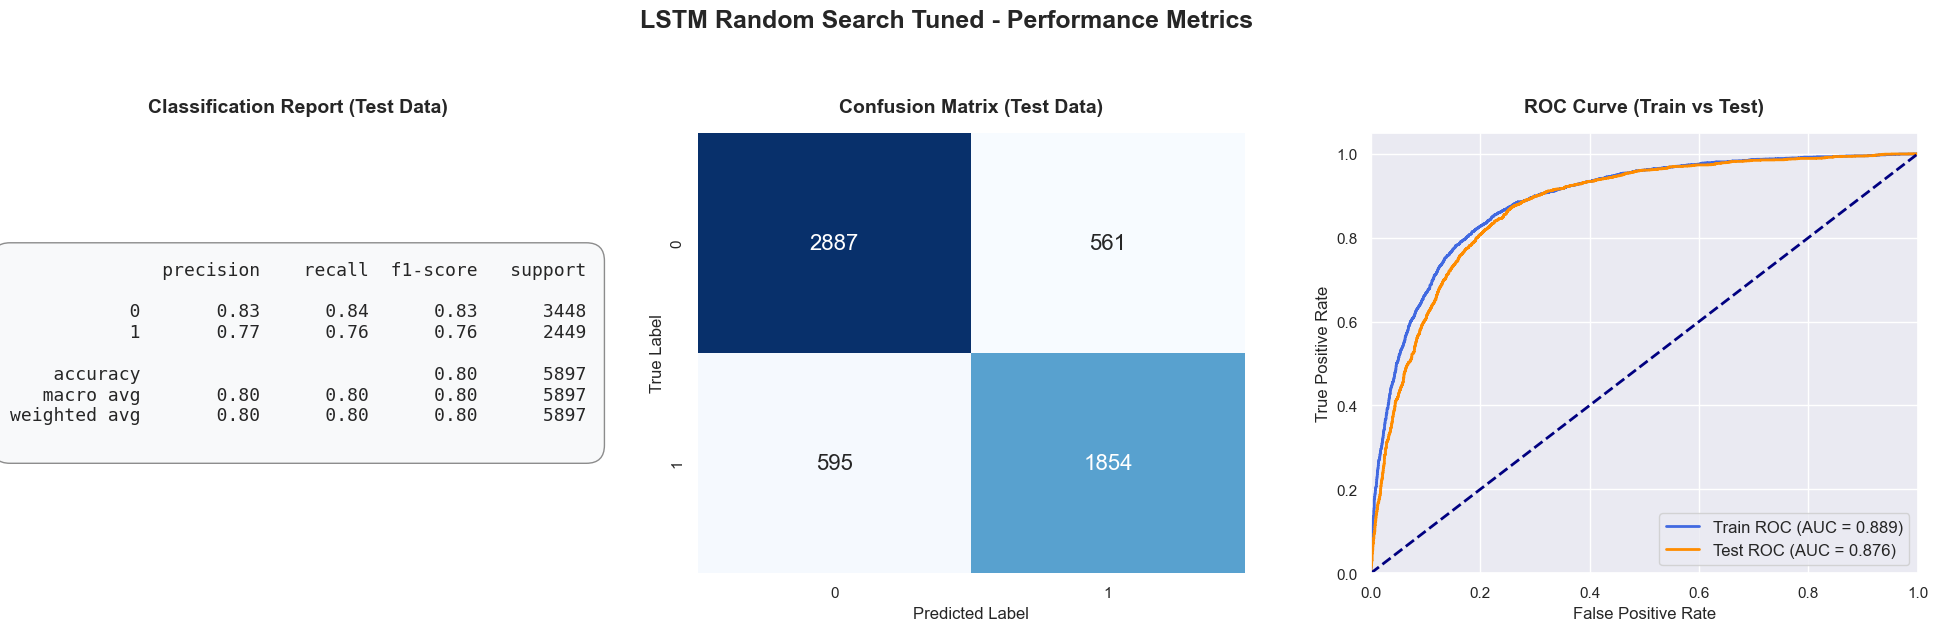

In [11]:
# 1. Pass the Tuner object directly so the function can extract the best model!
final_model = save_and_evaluate(rstuner, train_data=train_dataset, val_data=val_dataset)

# 2. Call the plotting function with the Tuner object and update the run name
plot_model_performance(training_result=rstuner,  train_data=train_dataset,  val_data=val_dataset,  run_name="LSTM Random Search Tuned")

### Approach 2 : BayesianOptimization

In [12]:
tf.keras.backend.clear_session()
gc.collect()
# 1. Create a dynamic project name and directory to bypass the Windows file lock
timestamp = int(time.time())
tf.keras.utils.set_random_seed(42)
bo_project_name = f"botrial_{timestamp}"
bo_log_dir = os.path.join(MASTER_LOG_DIR, bo_project_name)

# 2. Update the callback so TensorBoard points to this new unlocked directory
callback3 = [EarlyStopping(patience=5, monitor='val_loss', mode='min', verbose=1, restore_best_weights=True),
             make_tb_callback(bo_log_dir)]

# 3. Initialize BayesianOptimization with the dynamic project name and MASTER directory
botuner = BayesianOptimization(build_model, objective="val_loss", max_trials=20, num_initial_points=2, hyperparameters=None,
                               tune_new_entries=True, allow_new_entries=True, directory=MASTER_LOG_DIR,  project_name=bo_project_name, overwrite=True)

print("--- Starting Bayesian Optimization Search ---")
# IMPORTANT: keep TensorBoard launch in its OWN cell so Keras progress bars cannot clear the link
bo_tb_url = launch_tensorboard_for_dir(bo_log_dir, title=f"Bayesian Optimization | {bo_project_name}")
print("TensorBoard URL saved. Continue to next cell to start search.")


--- Starting Bayesian Optimization Search ---
[TensorBoard] Bayesian Optimization | botrial_1787142505 run=botrial_1787142505 -> http://localhost:6011/#scalars&runFilter=botrial_1787142505
TensorBoard URL saved. Continue to next cell to start search.


In [13]:
# 4. Launch tuning process (TensorBoard link remains in the previous cell output)
botuner.search(train_dataset, epochs=50, validation_data=val_dataset, callbacks=callback3, class_weight=class_weight, shuffle=False)

# 5. Display results
best_bohp = botuner.get_best_hyperparameters()[0]
print("\nBest Hyperparameters:\n", best_bohp.values)
print("\nSummary:\n")
botuner.results_summary()

gc.collect()


Trial 20 Complete [00h 00m 21s]
val_loss: 0.45520058274269104

Best val_loss So Far: 0.43560898303985596
Total elapsed time: 00h 07m 16s

Best Hyperparameters:
 {'units1': 20, 'units2': 20, 'units3': 8, 'Dropout_rate_1': 0.4, 'Dropout_rate_2': 0.30000000000000004, 'activation_1': 'relu', 'activation_2': 'elu', 'activation_3': 'relu', 'learning_rate': 0.01}

Summary:

Results summary
Results in C:\Users\mail2\AppData\Local\cqf_quant_model_logs\botrial_1787142505
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 15 summary
Hyperparameters:
units1: 20
units2: 20
units3: 8
Dropout_rate_1: 0.4
Dropout_rate_2: 0.30000000000000004
activation_1: relu
activation_2: elu
activation_3: relu
learning_rate: 0.01
Score: 0.43560898303985596

Trial 05 summary
Hyperparameters:
units1: 20
units2: 24
units3: 8
Dropout_rate_1: 0.30000000000000004
Dropout_rate_2: 0.2
activation_1: relu
activation_2: elu
activation_3: relu
learning_rate: 0.01
Score: 0.4383451044559479

Trial 12 summar

9306


[Extracted the best model from KerasTuner]
Model successfully saved to best_lstm_baseline.keras!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM1 (LSTM)                    │ (None, 21, 20)         │         4,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout1 (Dropout)              │ (None, 21, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM2 (LSTM)                    │ (None, 21, 20)         │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout2 (Dropout)              │ (None, 21, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM3 (LSTM)                    │ (None, 8)              │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,097 (35.54 KB)

 Trainable params: 9,097 (35.54 KB)

 Non-trainable params: 0 (0.00 B)


--- LSTM Model: Validation Performance ---
 - loss: 0.4356
 - compile_metrics: 0.8094

--- LSTM Model: Training Performance ---
 - loss: 0.4018
 - compile_metrics: 0.8254
Extracting model and generating metrics for: BayesianOptimization...


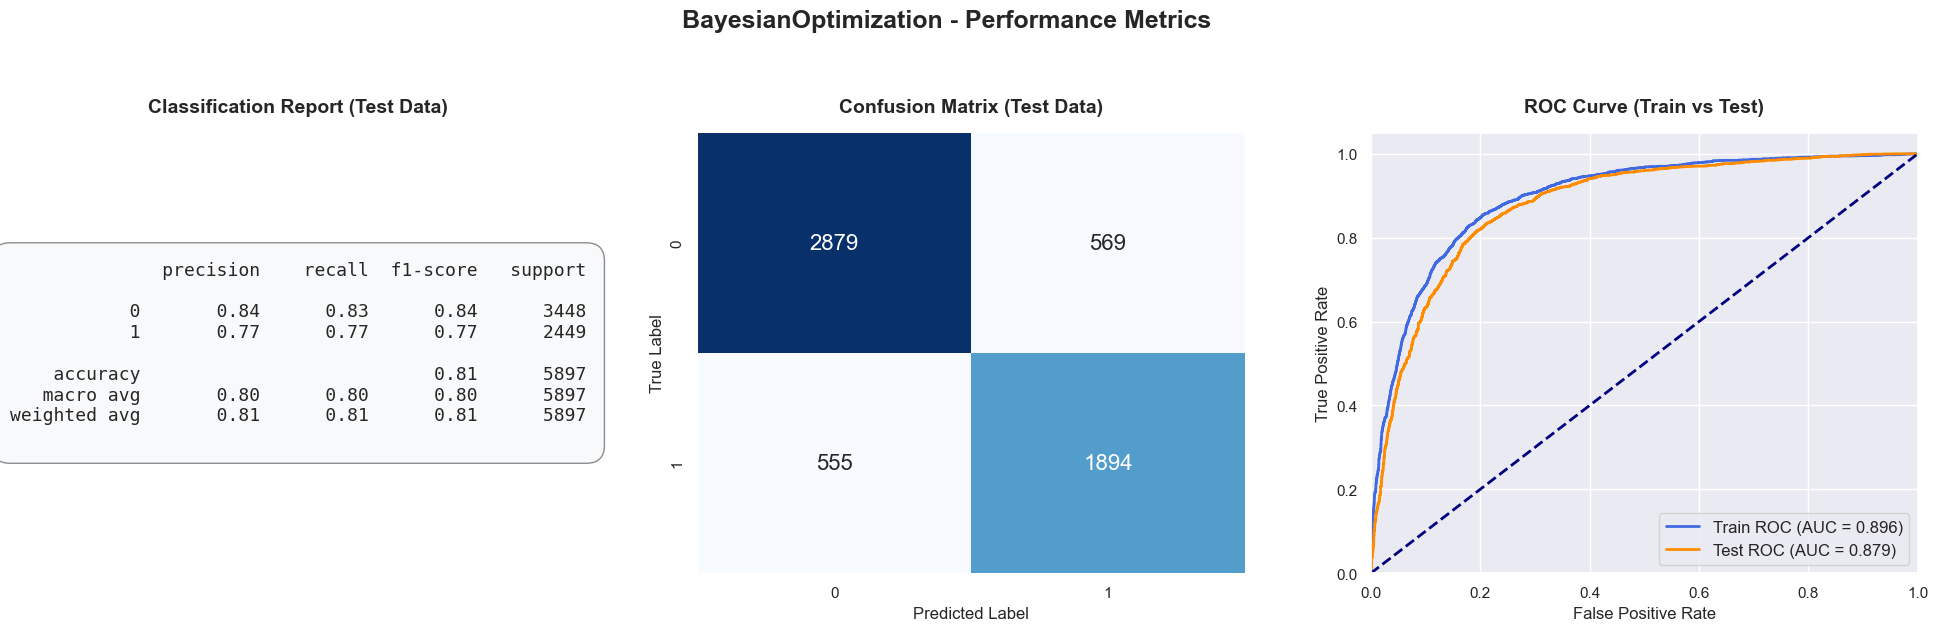

In [14]:
# 1. Pass the Tuner object directly so the function can extract the best model!
final_model = save_and_evaluate(botuner, train_data=train_dataset, val_data=val_dataset)

# 2. Call the plotting function with the Tuner object and update the run name
plot_model_performance(training_result=botuner,  train_data=train_dataset,  val_data=val_dataset,  run_name="BayesianOptimization")

### Approach 3 : HyperBand

In [15]:
tf.keras.backend.clear_session()
gc.collect()
# 1. Create a dynamic project name and directory to bypass the Windows file lock
timestamp = int(time.time())
tf.keras.utils.set_random_seed(42)
hb_project_name = f"hbtrial_{timestamp}"
hb_log_dir = os.path.join(MASTER_LOG_DIR, hb_project_name)

# 2. Update callback2 so TensorBoard points to this specific unlocked directory
callback2 = [EarlyStopping(patience=5, monitor='val_loss', mode='min', verbose=1, restore_best_weights=True),
             make_tb_callback(hb_log_dir)]

# 3. Initialize Hyperband with the dynamic project name and MASTER directory
hbtuner = kt.Hyperband(build_model, objective="val_loss", max_epochs=20, factor=4, hyperband_iterations=1,
                       directory=MASTER_LOG_DIR,  project_name=hb_project_name, overwrite=True)

print("--- Starting Hyperband Search ---")
# IMPORTANT: keep TensorBoard launch in its OWN cell so Keras progress bars cannot clear the link
hb_tb_url = launch_tensorboard_for_dir(hb_log_dir, title=f"Hyperband | {hb_project_name}")
print("TensorBoard URL saved. Continue to next cell to start search.")


--- Starting Hyperband Search ---
[TensorBoard] Hyperband | hbtrial_1787142957 run=hbtrial_1787142957 -> http://localhost:6012/#scalars&runFilter=hbtrial_1787142957
TensorBoard URL saved. Continue to next cell to start search.


In [16]:
# 4. Launch tuning process (TensorBoard link remains in the previous cell output)
hbtuner.search(train_dataset, epochs=20, validation_data=val_dataset, callbacks=callback2, class_weight=class_weight, shuffle=False)


# 5. Display results
best_hbhp = hbtuner.get_best_hyperparameters()[0]
print("\nBest Hyperparameters:\n", best_hbhp.values)
print("\nSummary:\n")
hbtuner.results_summary()

gc.collect()


Trial 44 Complete [00h 00m 26s]
val_loss: 0.44918376207351685

Best val_loss So Far: 0.43601086735725403
Total elapsed time: 00h 10m 08s

Best Hyperparameters:
 {'units1': 32, 'units2': 8, 'units3': 28, 'Dropout_rate_1': 0.30000000000000004, 'Dropout_rate_2': 0.0, 'activation_1': 'elu', 'activation_2': 'elu', 'activation_3': 'elu', 'learning_rate': 0.01, 'tuner/epochs': 20, 'tuner/initial_epoch': 5, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0022'}

Summary:

Results summary
Results in C:\Users\mail2\AppData\Local\cqf_quant_model_logs\hbtrial_1787142957
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0028 summary
Hyperparameters:
units1: 32
units2: 8
units3: 28
Dropout_rate_1: 0.30000000000000004
Dropout_rate_2: 0.0
activation_1: elu
activation_2: elu
activation_3: elu
learning_rate: 0.01
tuner/epochs: 20
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0022
Score: 0.43601086735725403

Trial 0035 summary
Hyperparameters:
uni

9556


[Extracted the best model from KerasTuner]
Model successfully saved to best_lstm_baseline.keras!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM1 (LSTM)                    │ (None, 21, 32)         │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout1 (Dropout)              │ (None, 21, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM2 (LSTM)                    │ (None, 21, 8)          │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout2 (Dropout)              │ (None, 21, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM3 (LSTM)                    │ (None, 28)             │         4,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            29 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,829 (57.93 KB)

 Trainable params: 14,829 (57.93 KB)

 Non-trainable params: 0 (0.00 B)


--- LSTM Model: Validation Performance ---
 - loss: 0.4360
 - compile_metrics: 0.8040

--- LSTM Model: Training Performance ---
 - loss: 0.4324
 - compile_metrics: 0.8014
Extracting model and generating metrics for: LSTM Hyperband Search Tuned...


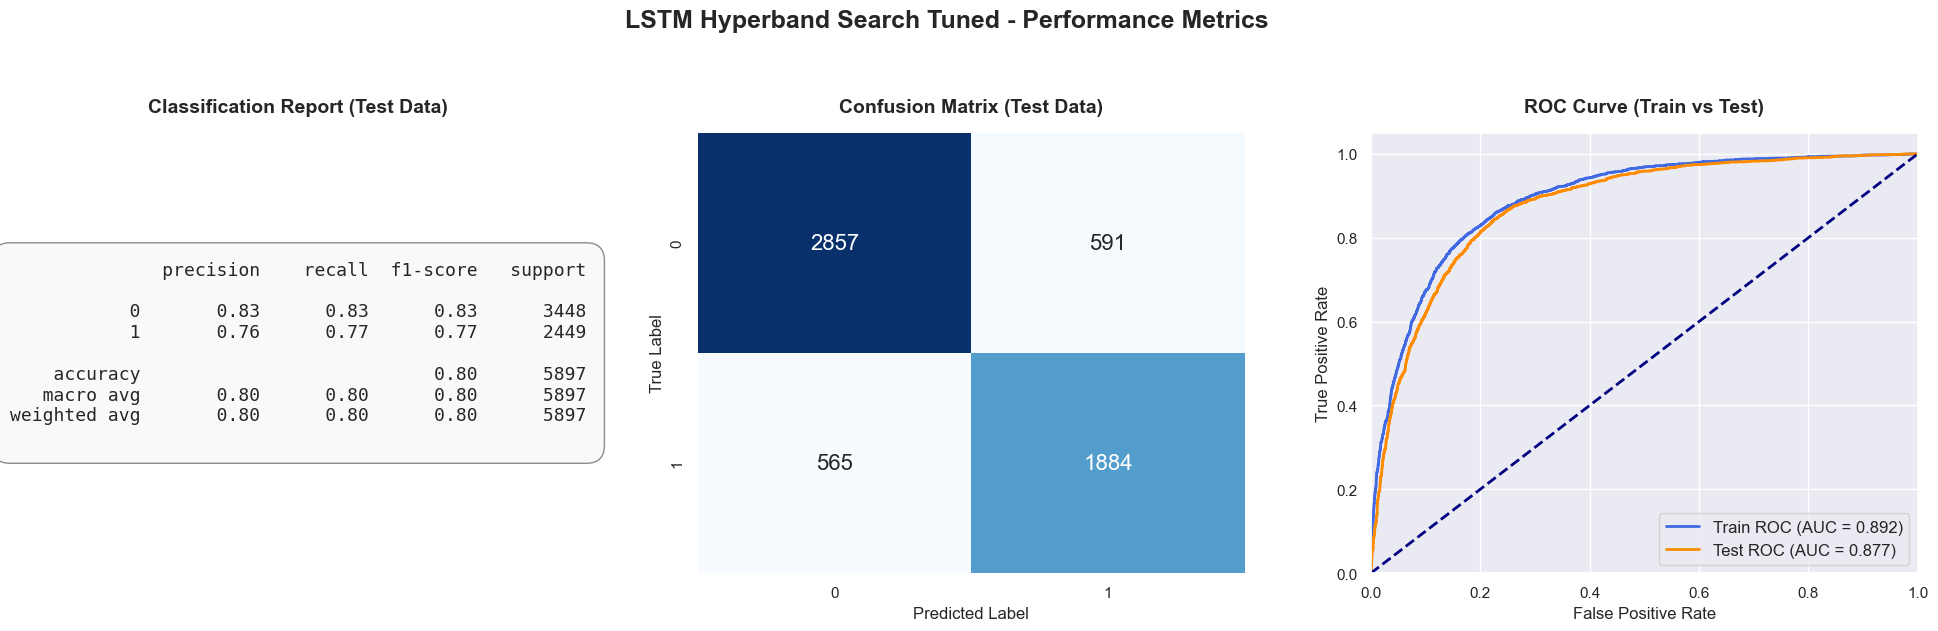

In [17]:
# 1. Pass the Tuner object directly so the function can extract the best model!
final_model = save_and_evaluate(hbtuner, train_data=train_dataset, val_data=val_dataset)

# 2. Call the plotting function with the Tuner object and update the run name
plot_model_performance(training_result=hbtuner,  train_data=train_dataset,  val_data=val_dataset,  run_name="LSTM Hyperband Search Tuned")

# Backtesting

### Selecting the Model for backtesting

In [18]:
### Multi-model backtest comparison
#Run every candidate through the same lagged, cost-aware long/cash backtest. 
# The table ranks models on trading metrics (not validation loss) and assigns `absolute_best_model` 
# to the backtest winner.


  MULTI-MODEL BACKTEST  |  lag-1 execution, 5+5 bps round-trip friction
Annualization: 1764 bars/year (median bars/day x 252). Ranked on: Net Return, CAGR, Sharpe, Sortino, Calmar, Profit Factor, Excess vs Market, Trade Win Rate, Information Ratio, Max Drawdown, Ulcer Index.



Model,Baseline Model,Random Search,Bayesian Optimization,Hyperband,Buy & Hold
Log Loss,0.458,0.439,0.436,0.436,—
Accuracy,79.77%,80.40%,80.94%,80.40%,—
Balanced Accuracy,79.59%,79.72%,80.42%,79.89%,—
ROC AUC,0.871,0.876,0.879,0.877,—
F1,0.763,0.762,0.771,0.765,—
Net Return,2105.30%,1586.62%,1950.38%,1650.96%,115.98%
CAGR,149.10%,130.15%,143.80%,132.71%,25.51%
Excess vs Market,1989.32%,1470.64%,1834.40%,1534.98%,0.00%
Sharpe,8.809,8.237,8.917,8.340,1.555
Sortino,21.512,20.287,23.209,20.791,2.185



Average rank (1 = best). Winner = lowest Avg Rank.


,Baseline Model,Bayesian Optimization,Hyperband,Random Search
Net Return,1.00,2.00,3.00,4.00
CAGR,1.00,2.00,3.00,4.00
Sharpe,2.00,1.00,3.00,4.00
Sortino,2.00,1.00,3.00,4.00
Calmar,1.00,2.00,3.00,4.00
Profit Factor,2.00,1.00,3.00,4.00
Excess vs Market,1.00,2.00,3.00,4.00
Trade Win Rate,1.00,2.00,4.00,3.00
Information Ratio,1.00,2.00,3.00,4.00
Max Drawdown,3.00,4.00,2.00,1.00



  BACKTEST WINNER: Baseline Model  (Avg Rank 1.55)


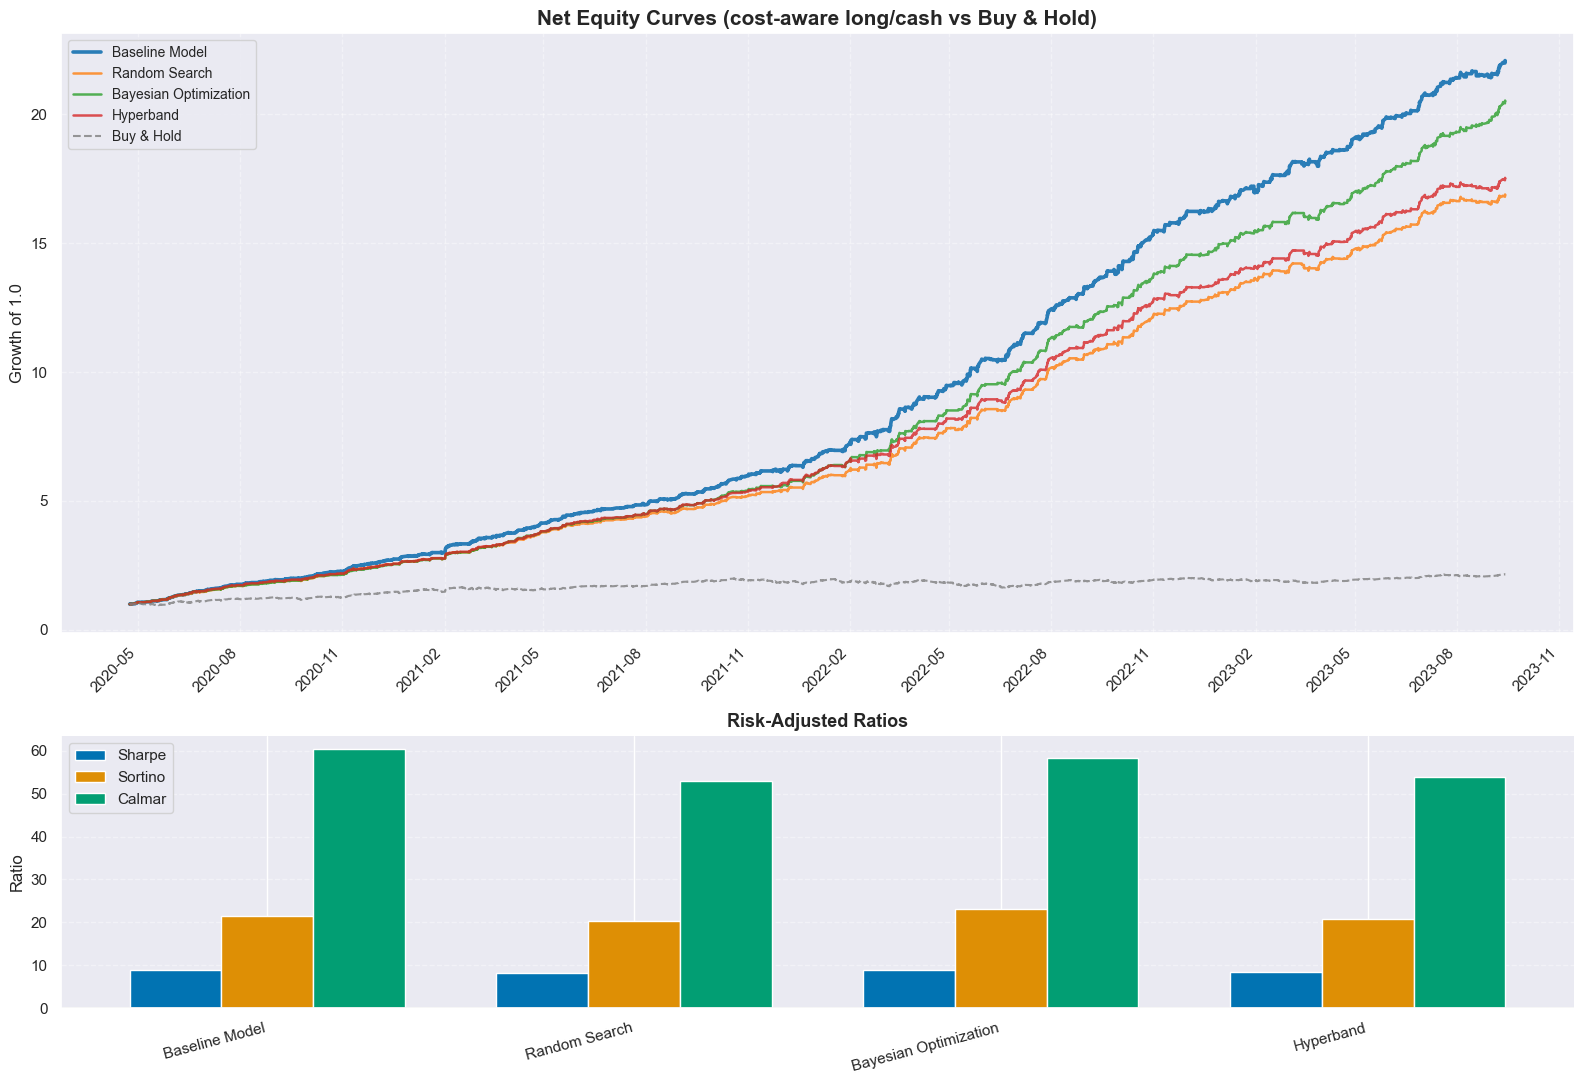

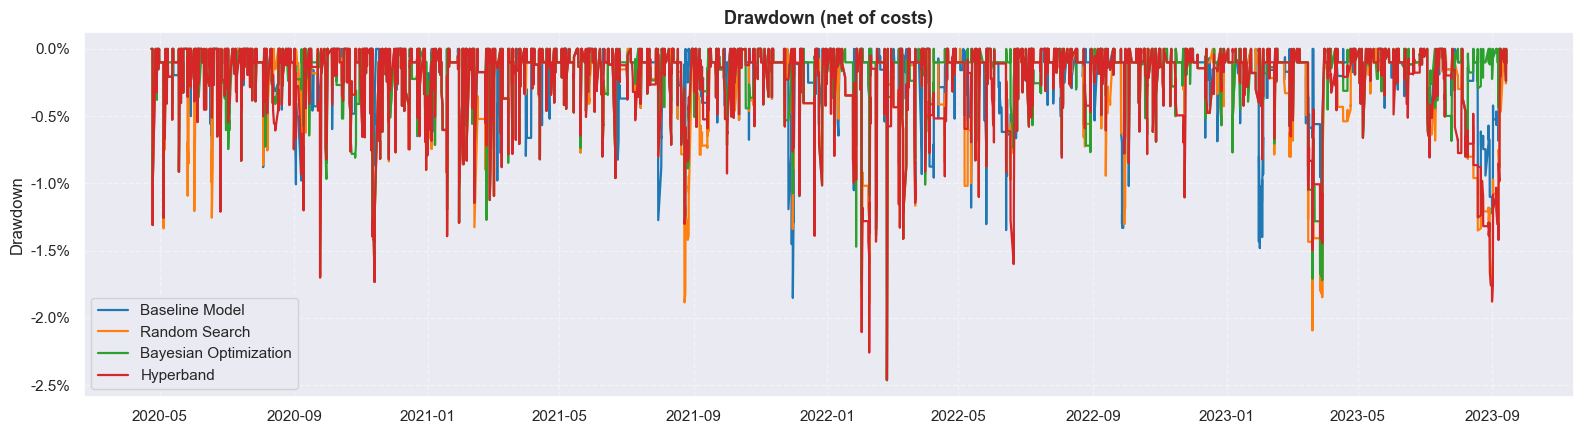


Final selection (backtest composite rank): Baseline Model
Assigned to `absolute_best_model` / `bt_best_model`.


In [19]:
# Same candidate set as the classification table. Re-run parked functions first
# so `compare_models_backtest` is defined after a kernel restart.
models = {
    "Baseline Model": model,
    "Random Search": rstuner,
    "Bayesian Optimization": botuner,
    "Hyperband": hbtuner,
}

save_dir = PROJECT_PATH / "data"
df = pd.read_pickle(save_dir / "df_boruta.pkl")

bt_results = compare_models_backtest(
    models=models,
    val_data=val_dataset,
    df=df,
    tc_bps=5,
    slippage_bps=5,
)

bt_best_model_name = bt_results["winner_name"]
bt_best_model = bt_results["winner_model"]
absolute_best_model = bt_best_model

print(f"\nFinal selection (backtest composite rank): {bt_best_model_name}")
print("Assigned to `absolute_best_model` / `bt_best_model`.")


### MCDM selection (TOPSIS + weighted composite index)
Uses the backtest metrics table. Equal category weights by default; override with `SelectorWeights`.
The consensus winner is assigned to `absolute_best_model`.


  MODEL SELECTOR  |  TOPSIS + Weighted Composite Index
Weights (normalized): Return 40% | Risk 30% | Stability 30%
Per-metric TOPSIS weights (category split equally inside each bucket):


,Net Return,CAGR,Profit Factor,Max Drawdown,Ulcer Index,Sharpe,Sortino,Calmar,Positive Months
Weight,0.133333,0.133333,0.133333,0.15,0.15,0.075,0.075,0.075,0.075
Direction,+,+,+,-,-,+,+,+,+
Category,return,return,return,risk,risk,stability,stability,stability,stability



Decision matrix (risk metrics as magnitudes to minimize):


Model,Baseline Model,Random Search,Bayesian Optimization,Hyperband
Net Return,21.0530,15.8662,19.5038,16.5096
CAGR,1.4910,1.3015,1.4380,1.3271
Profit Factor,2.6193,2.5243,2.7713,2.5344
Max Drawdown,0.0246,0.0246,0.0246,0.0246
Ulcer Index,0.0032,0.0041,0.0030,0.0039
Sharpe,8.8093,8.2368,8.9170,8.3396
Sortino,21.5121,20.2875,23.2093,20.7910
Calmar,60.5311,52.9014,58.3810,53.9405
Positive Months,1.0000,0.9762,1.0000,0.9762



TOPSIS (C* closer to 1 is better):


...


Weighted composite index (category scores 0–1):


Model,Bayesian Optimization,Baseline Model,Hyperband,Random Search
Return,0.8073,0.7949,0.0999,0.0000
Risk,0.5000,0.4461,0.5991,0.5000
Stability,0.9295,0.8152,0.1149,0.0000
Composite Index,0.7518,0.6963,0.2542,0.1500
Composite Rank,1.0000,2.0000,3.0000,4.0000



Consensus ranking (average of TOPSIS rank and Composite rank):


Model,Baseline Model,Bayesian Optimization,Hyperband,Random Search
TOPSIS C*,0.8445,0.8180,0.1637,0.0027
TOPSIS Rank,1.0000,2.0000,3.0000,4.0000
Composite Index,0.6963,0.7518,0.2542,0.1500
Composite Rank,2.0000,1.0000,3.0000,4.0000
Avg Rank,1.5000,1.5000,3.0000,4.0000
Consensus Rank,1.0000,1.0000,3.0000,4.0000
Return,0.7949,0.8073,0.0999,0.0000
Risk,0.4461,0.5000,0.5991,0.5000
Stability,0.8152,0.9295,0.1149,0.0000



Selected model: Baseline Model  (method = consensus).
Category weights — Return 40%, Risk 30%, Stability 30%.
Baseline Model TOPSIS C* = 0.844 (rank 1), Composite = 0.696 (rank 2), consensus rank = 1.
Category scores (0–1, higher is better): Return 0.795, Risk 0.446, Stability 0.815.
Runner-up: Bayesian Optimization (TOPSIS C* 0.818, Composite 0.752).
Baseline Model beats Bayesian Optimization on: Net Return (21.05 vs 19.5), CAGR (1.491 vs 1.438), Max Drawdown (0.02463 vs 0.02463), Calmar (60.53 vs 58.38).
Remaining candidates in consensus order after Bayesian Optimization: Hyperband, Random Search.

  MCDM WINNER: Baseline Model  (method=consensus)


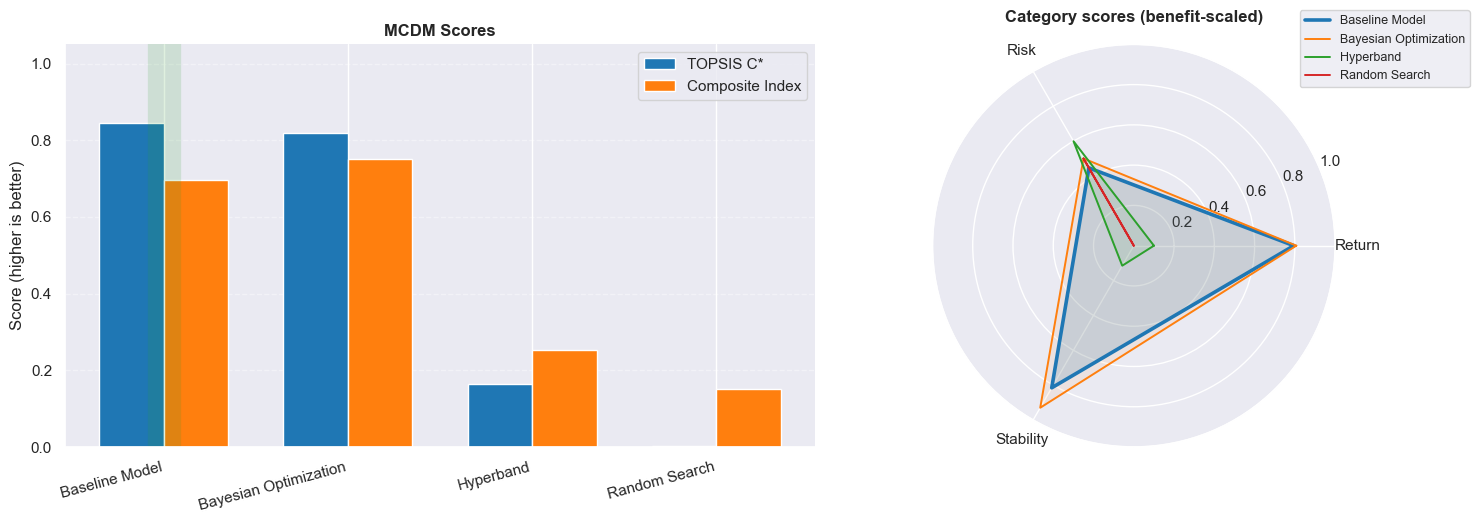


Final selection (MCDM consensus): Baseline Model
Assigned to `absolute_best_model` / `mcdm_best_model`.


In [20]:
# Requires compare_models_backtest to have been run (bt_results, models).
sel = model_selector(
    bt_results["metrics"],
    models=models,
    weights=SelectorWeights(return_weight=0.40, risk_weight=0.30, stability_weight=0.30),
    method="consensus",
    exclude=("Buy & Hold",),
    show=True,
)

mcdm_best_model_name = sel.winner_name
mcdm_best_model = sel.winner_model
absolute_best_model = mcdm_best_model

print(f"\nFinal selection (MCDM {sel.method}): {mcdm_best_model_name}")
print("Assigned to `absolute_best_model` / `mcdm_best_model`.")


### Final Backtest Visualization (MCDM-Selected Model)
The equity-curve and period-metric charts previously shown right after model
selection (which ran on the naive lowest-validation-loss model) are now generated
once here, on the actual final model chosen by TOPSIS + weighted composite index
(`mcdm_best_model`).


BACKTEST VISUALIZATION: MCDM Winner: Baseline Model


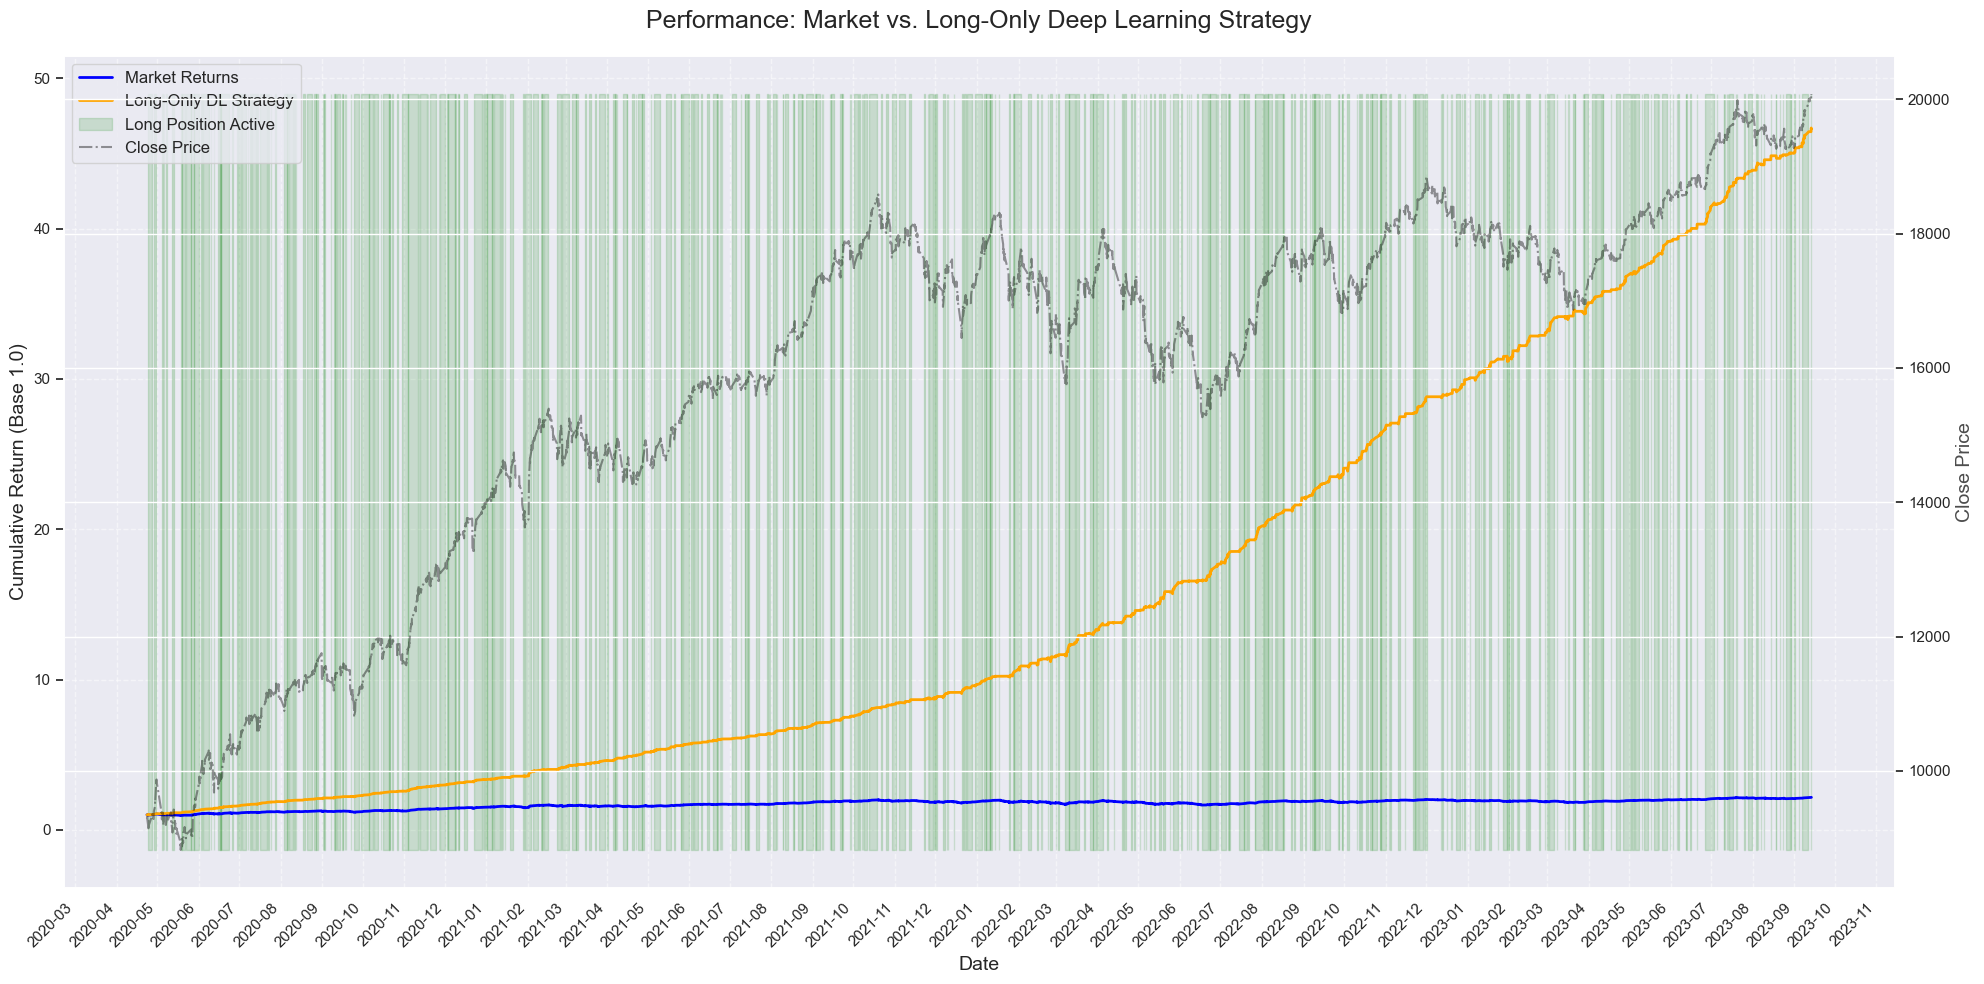

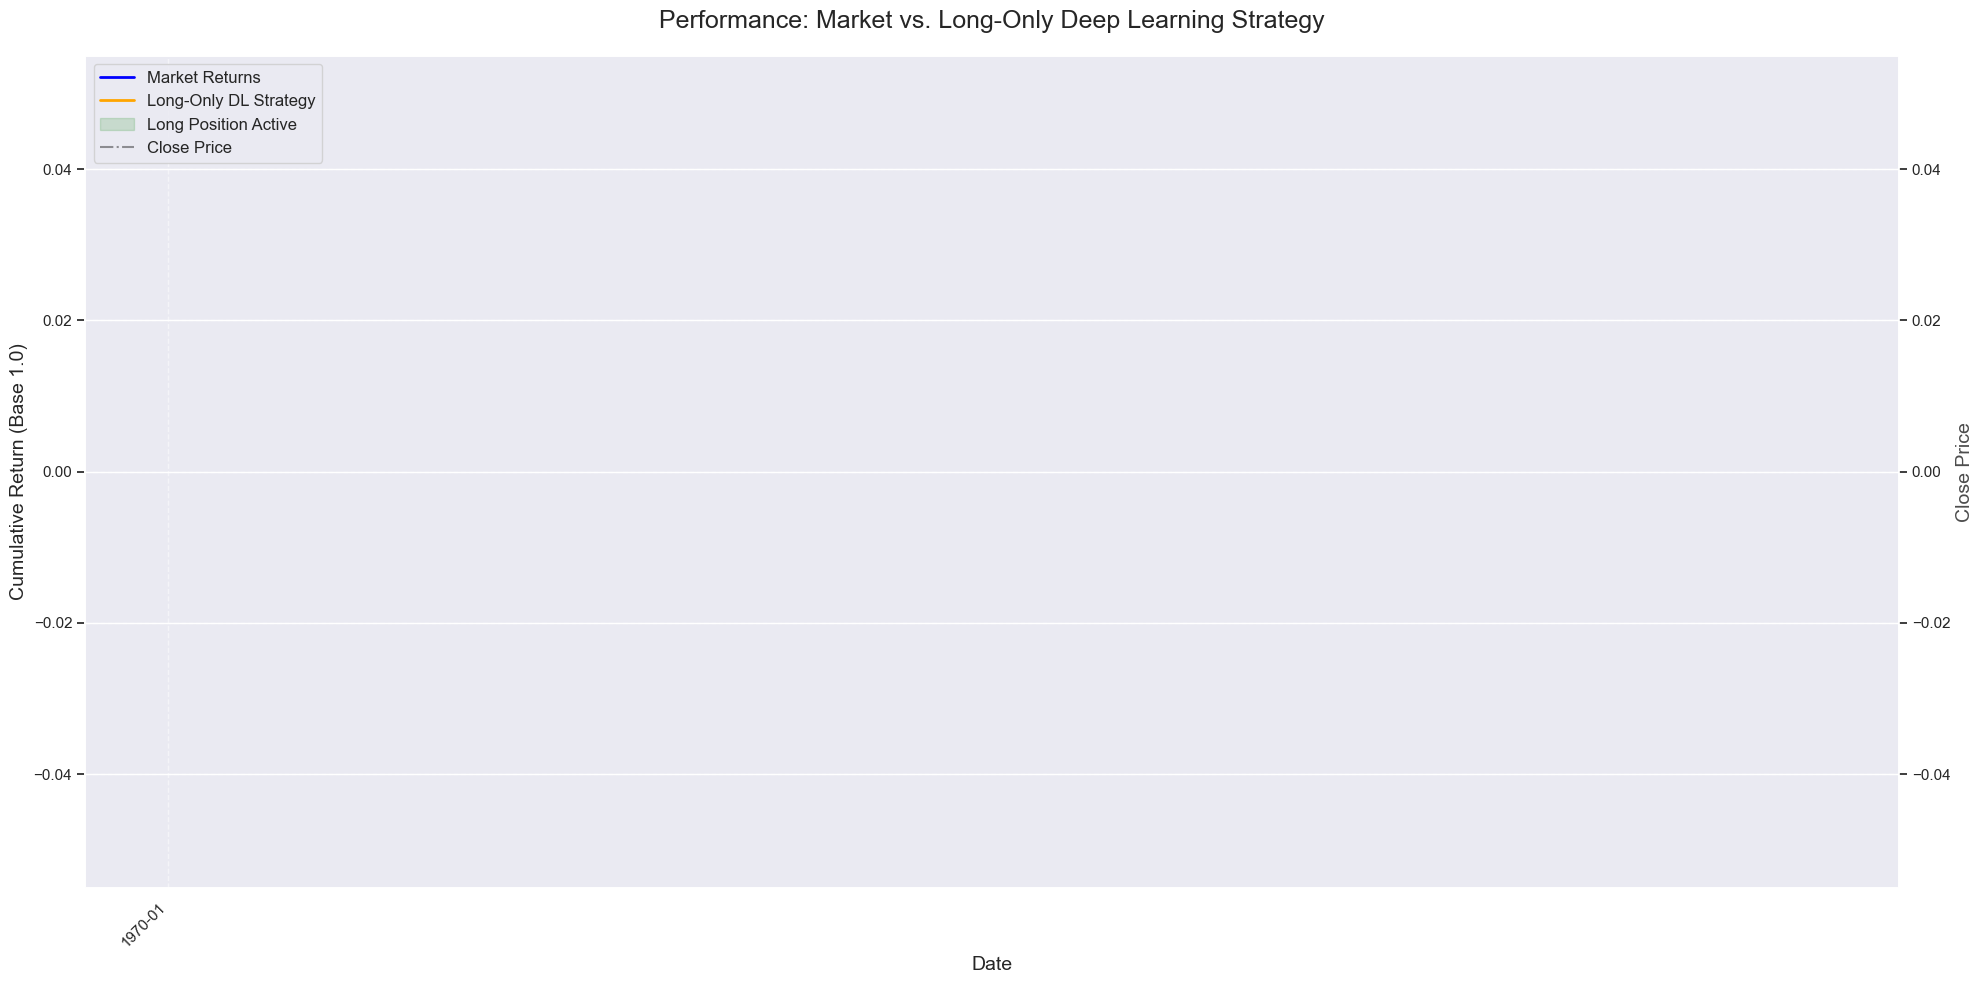


 📅 YEARLY METRICS
             Return Sharpe  Max_DD
datetime                          
2020-12-31  185.24%   4.37  -1.69%
2021-12-31  133.96%   3.28  -1.85%
2022-12-31  148.75%   3.12  -2.46%
2023-12-31   32.85%   2.55  -1.53%

 📅 QUARTERLY METRICS
            Return Sharpe  Max_DD
datetime                         
2020-06-30  52.85%   4.94  -1.31%
2020-09-30  33.56%   4.05  -1.69%
2020-12-31  39.72%   4.45  -1.30%
2021-03-31  31.41%   3.20  -1.29%
2021-06-30  25.06%   3.98  -0.96%
2021-09-30  17.52%   3.55  -1.27%
2021-12-31  21.15%   2.99  -1.85%
2022-03-31  30.89%   2.94  -2.46%
2022-06-30  26.52%   3.03  -1.35%
2022-09-30  27.61%   3.98  -1.33%
2022-12-31  17.71%   2.90  -0.92%
2023-03-31  10.51%   2.02  -1.53%
2023-06-30  12.65%   3.80  -0.66%
2023-09-30   6.71%   2.27  -1.22%

 📅 MONTHLY METRICS
            Return Sharpe  Max_DD
datetime                         
2020-04-30   7.30%   4.68  -1.31%
2020-05-31  15.82%   4.75  -1.16%
2020-06-30  23.00%   5.32  -0.91%
2020-07-31  15.

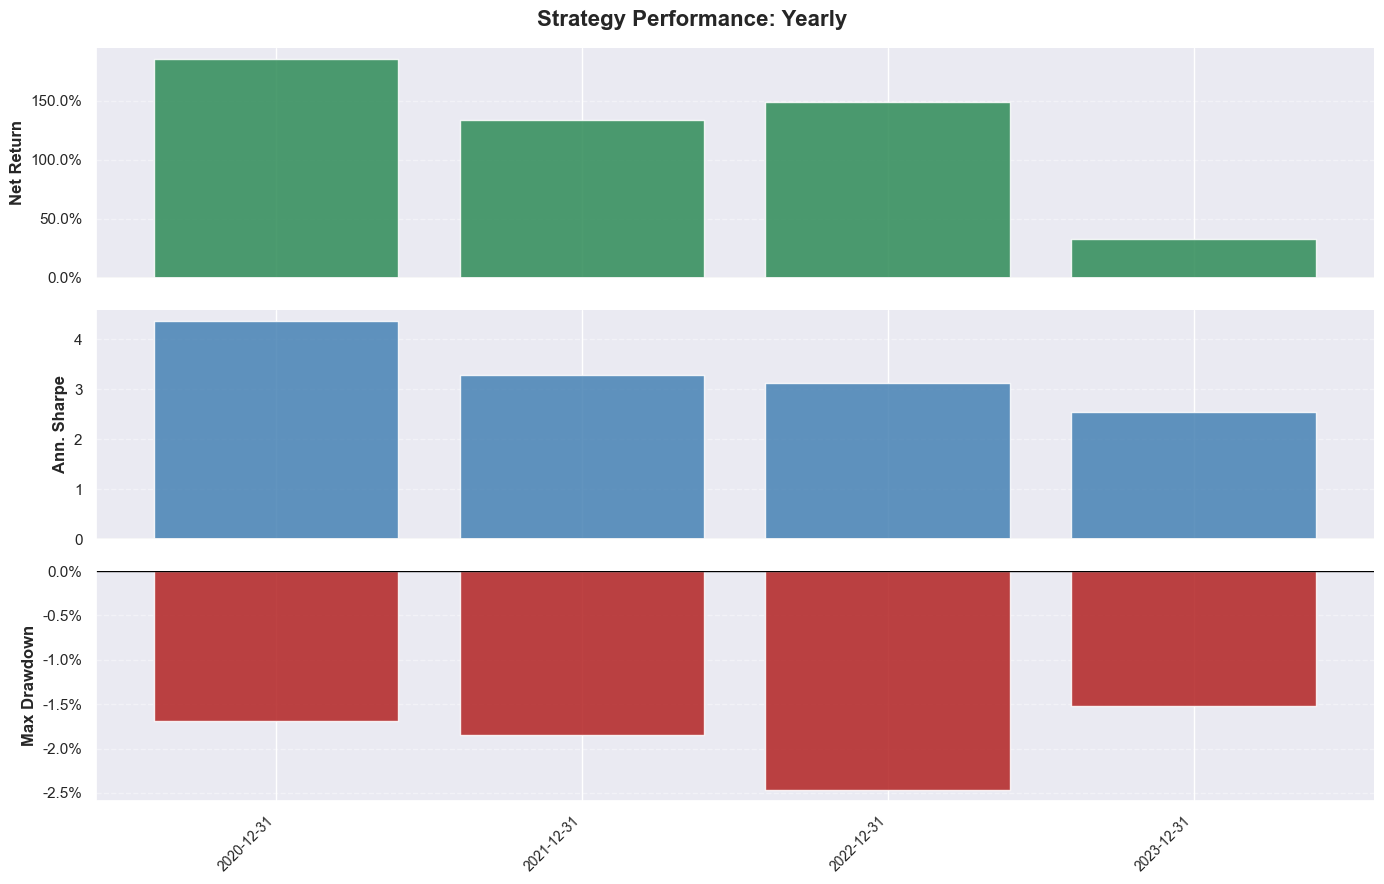

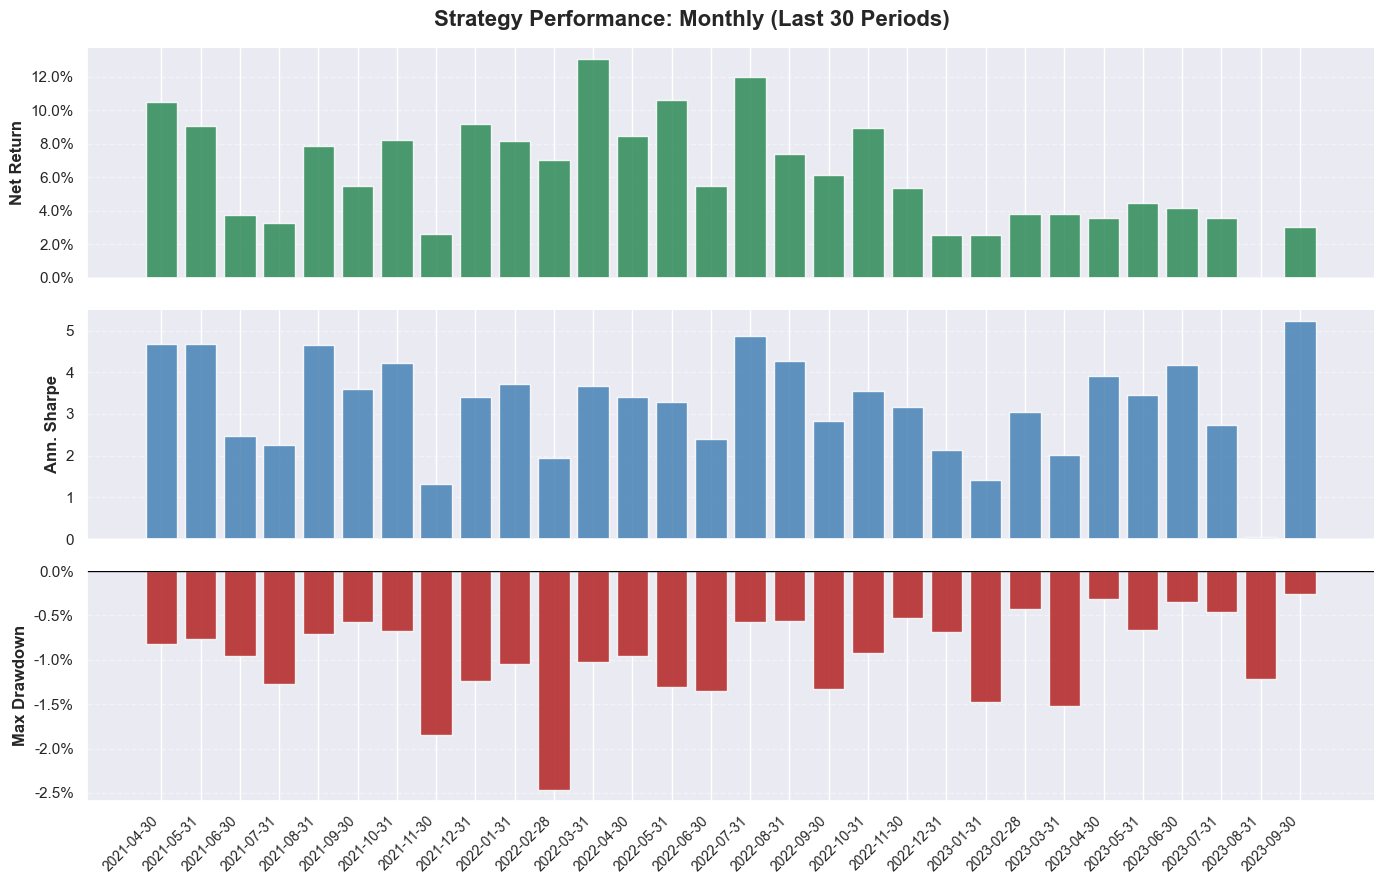

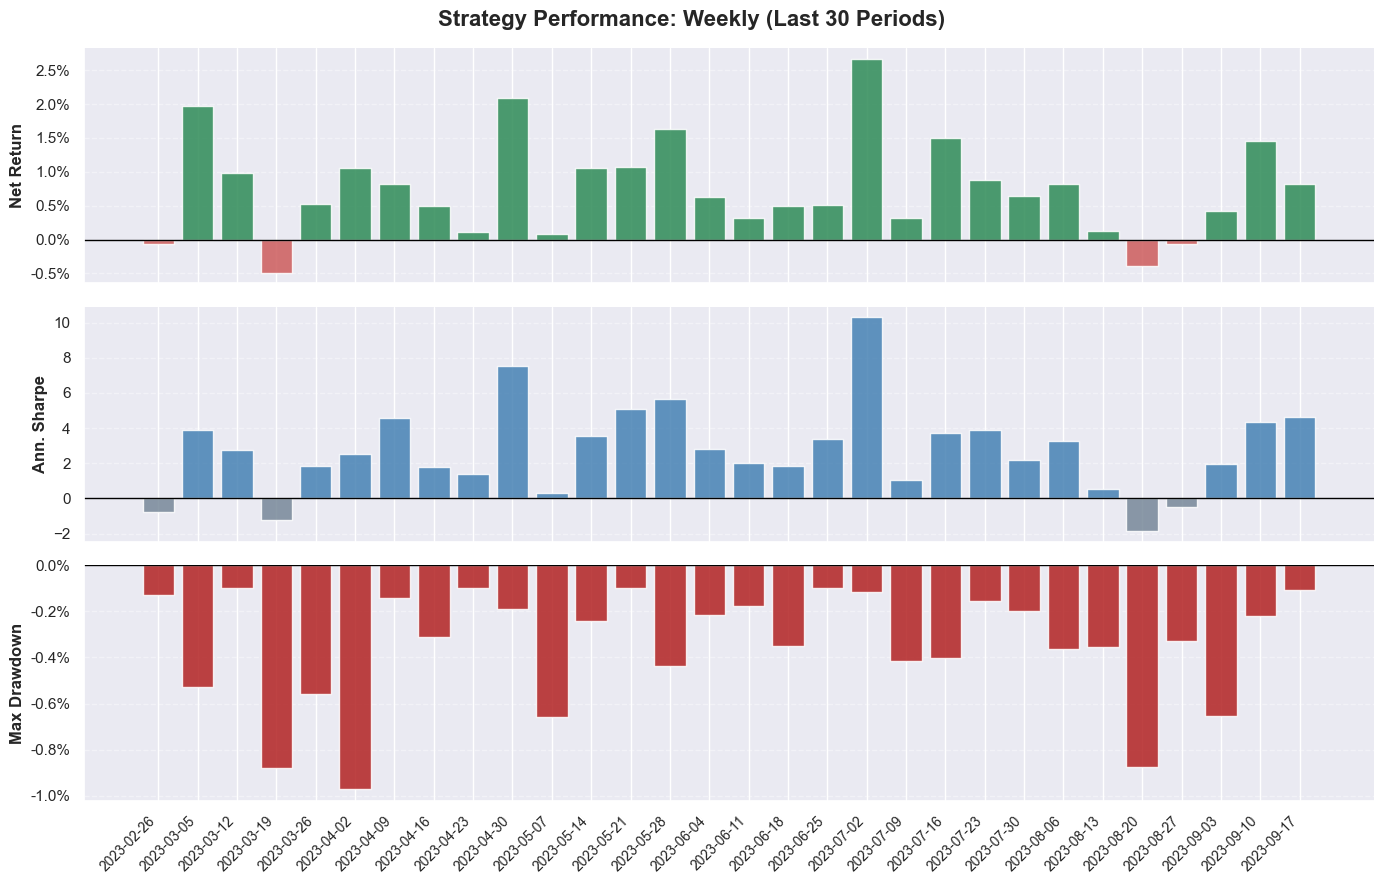

In [21]:
import matplotlib.dates as mdates
viz_results = visualize_final_model_strategy(
    model=mcdm_best_model,
    df=df,
    val_data=val_dataset,
    model_name=f"MCDM Winner: {mcdm_best_model_name}",
    tc_bps=5,
    slippage_bps=5,
    zoom_start='2026-01-01',
    zoom_end='2026-05-31',
)

### Persist the final selected model for deployment
`absolute_best_model` only exists inside this kernel session. To reuse the exact MCDM-selected
model outside this notebook (e.g. to score brand-new raw OHLCV data), save it to disk together
with a small metadata file recording which candidate won and the input shape it expects.
Consumed by `source/end_to_end_pipeline/raw_data_to_signal.ipynb`.

In [22]:
import json

model_dir = PROJECT_PATH / "data" / "models"
model_dir.mkdir(parents=True, exist_ok=True)
best_model_path = model_dir / "absolute_best_model.keras"
absolute_best_model.save(best_model_path)

with open(model_dir / "absolute_best_model_meta.json", "w") as f:
    json.dump({
        "winner_name": mcdm_best_model_name,
        "selection_method": sel.method,
        "seqlen": int(SEQLEN),
        "numfeat": int(NUMFEAT),
    }, f, indent=2)

print(f"Saved final selected model ('{mcdm_best_model_name}') to {best_model_path}")
print(f"Saved metadata to {model_dir / 'absolute_best_model_meta.json'}")

Saved final selected model ('Baseline Model') to c:\Users\mail2\OneDrive\coding projects\Final Project\data\models\absolute_best_model.keras
Saved metadata to c:\Users\mail2\OneDrive\coding projects\Final Project\data\models\absolute_best_model_meta.json
